# Input-beam Gaussian fit after fiber re-coupling — 2026-07-24

Question: did re-coupling the free-space laser into the fiber change the
Gaussian input beam? Data: `profiler/data/auto_scan-2026-07-24_10-41-24`
(placement `jul24-inputbeam-001`, bare beam after the 60FC-L collimator,
5 slices at y = 26–34 cm, OpticConfiguration waist/L12/L23 = null).

Method: identical to `beam_gaussian_fit_analysis_2026_07_09.ipynb` — rotated
2D elliptical Gaussian fit, 1/e² diameter D = 4σ, super-Gaussian shape check
— applied to the per-slice **ds-2 composites** (the ~4.6 mm beam overfills a
single 7.1×5.3 mm frame, so the position-stitched composite is the whole-beam
image; feather-averaged counts, background-subtracted). One difference from
jul09: NShots = 1 per raster point, so there is no shot-jitter analysis;
instead the five y-slices give an independent-measurement spread and a
pointing (tilt) estimate.

References for comparison: jul09 per-shot result **4.67 × 4.64 mm**
(ellipticity 1.007, R² ≈ 0.99, super-Gaussian n ≈ 0.9); config value 4.59 mm.

In [1]:
import glob
import json
from pathlib import Path

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

RUN = "../profiler/data/auto_scan-2026-07-24_10-41-24"
PX = 2 * 3.45e-3          # mm per composite pixel (ds 2)

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "beam_gaussian_fit_analysis_2026_07_24"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")


def gauss2d(coords, A, x0, y0, sx, sy, theta, off):
    """Rotated 2D elliptical Gaussian (as in the jul09 notebook)."""
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    return off + A * np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))


def supergauss2d(coords, A, x0, y0, sx, sy, theta, off, n):
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    q = xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)
    return off + A * np.exp(-q**n)


def crop_to_beam(frame, thresh=10, pad=40):    # pad 40 ds2-px ~ jul09's 80 raw px
    mask = frame > thresh
    r0, r1 = np.where(np.any(mask, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(mask, axis=0))[0][[0, -1]]
    r0 = max(r0 - pad, 0); r1 = min(r1 + pad, frame.shape[0] - 1)
    c0 = max(c0 - pad, 0); c1 = min(c1 + pad, frame.shape[1] - 1)
    return frame[r0:r1 + 1, c0:c1 + 1], r0, c0


def fit_gauss2d(img):
    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    tot = img.sum()
    x0g = (X * img).sum() / tot
    y0g = (Y * img).sum() / tot
    sxg = np.sqrt(np.abs(((X - x0g)**2 * img).sum() / tot))
    syg = np.sqrt(np.abs(((Y - y0g)**2 * img).sum() / tot))
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt, pcov = curve_fit(gauss2d, xy, img.ravel(),
                           p0=[img.max(), x0g, y0g, sxg, syg, 0.0, 0.0])
    fit = gauss2d(xy, *popt).reshape(img.shape)
    r2 = 1 - ((img - fit)**2).sum() / ((img - img.mean())**2).sum()
    return popt, np.sqrt(np.diag(pcov)), fit, r2


rows = []
for sd in sorted(glob.glob(RUN + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2, f"{sd}: composite at ds={meta['Downsample']}"
    img, r0, c0 = crop_to_beam(comp)
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    th_maj = th if sx >= sy else th + np.pi / 2

    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt_sg, _ = curve_fit(supergauss2d, xy, img.ravel(),
                           p0=list(popt) + [1.0], maxfev=20000)
    fit_sg = supergauss2d(xy, *popt_sg).reshape(img.shape)
    r2_sg = 1 - ((img - fit_sg)**2).sum() / ((img - img.mean())**2).sum()

    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sg=popt_sg[-1], r2_sg=r2_sg,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        off=off, peak=float(comp.max()),
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
        img=img, fit=fit, x0=x0, y0=y0,
        s_maj=s_maj, s_min=s_min, th_maj=th_maj,
    ))
    r = rows[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  R2 {r2:.4f}  n_sg {r['n_sg']:.3f}  "
          f"peak {r['peak']:.0f} counts  center ({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm")

Dm = np.array([r["D_maj"] for r in rows])
Dn = np.array([r["D_min"] for r in rows])
yy = np.array([r["y_cm"] for r in rows])
print(f"\nD_major = {Dm.mean():.3f} ± {Dm.std():.3f} mm   "
      f"D_minor = {Dn.mean():.3f} ± {Dn.std():.3f} mm   "
      f"geometric mean {np.sqrt(Dm.mean() * Dn.mean()):.3f} mm")
cx = np.polyfit(yy * 10, [r["xc_mm"] for r in rows], 1)
cz = np.polyfit(yy * 10, [r["zc_mm"] for r in rows], 1)
print(f"pointing: dX/dy = {cx[0]*1e3:+.2f} mrad, dZ/dy = {cz[0]*1e3:+.2f} mrad")

y= 26.0 cm  D = 4.632 x 4.493 mm  ellip 1.031  R2 0.9933  n_sg 0.926  peak 107 counts  center (59.97, -98.55) mm
y= 28.0 cm  D = 4.546 x 4.518 mm  ellip 1.006  R2 0.9939  n_sg 0.916  peak 104 counts  center (59.98, -98.45) mm
y= 30.0 cm  D = 4.524 x 4.484 mm  ellip 1.009  R2 0.9941  n_sg 0.912  peak 103 counts  center (59.99, -98.43) mm
y= 32.0 cm  D = 4.575 x 4.529 mm  ellip 1.010  R2 0.9925  n_sg 0.910  peak 105 counts  center (59.99, -98.37) mm
y= 34.0 cm  D = 4.639 x 4.597 mm  ellip 1.009  R2 0.9935  n_sg 0.902  peak 206 counts  center (60.00, -98.34) mm

D_major = 4.583 ± 0.045 mm   D_minor = 4.524 ± 0.040 mm   geometric mean 4.554 mm
pointing: dX/dy = +0.37 mrad, dZ/dy = +2.49 mrad


saved images/beam_gaussian_fit_analysis_2026_07_24/beam_gaussian_fit_analysis_2026_07_24.png


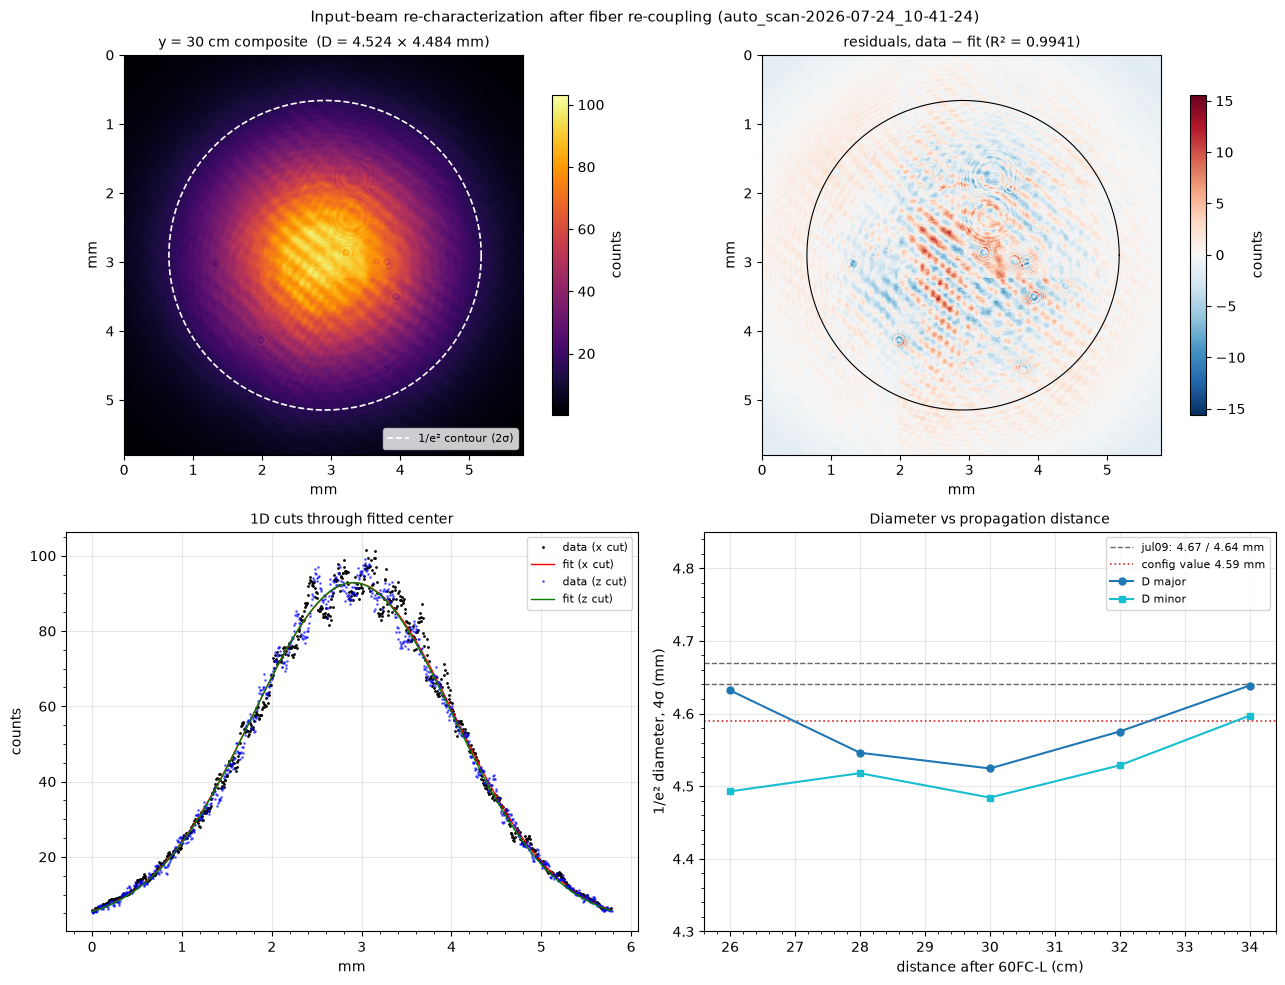

In [2]:
rep = rows[2]                     # y = 30 cm as the representative slice
img, fit = rep["img"], rep["fit"]
x0, y0 = rep["x0"], rep["y0"]
s_maj, s_min, th = rep["s_maj"], rep["s_min"], rep["th_maj"]

fig, axs = plt.subplots(2, 2, figsize=(13, 10))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im0 = axs[0, 0].imshow(img, cmap="inferno", extent=extent)
t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2 * s_maj * np.cos(t) * np.cos(th)
      - 2 * s_min * np.sin(t) * np.sin(th)) * PX
ey = (y0 + 2 * s_maj * np.cos(t) * np.sin(th)
      + 2 * s_min * np.sin(t) * np.cos(th)) * PX
axs[0, 0].plot(ex, ey, "w--", lw=1.2, label="1/e² contour (2σ)")
axs[0, 0].set_title(f"y = {rep['y_cm']:g} cm composite  "
                    f"(D = {rep['D_maj']:.3f} × {rep['D_min']:.3f} mm)",
                    fontsize=10)
axs[0, 0].set_xlabel("mm"); axs[0, 0].set_ylabel("mm")
axs[0, 0].legend(fontsize=8, loc="lower right")
plt.colorbar(im0, ax=axs[0, 0], shrink=0.8, label="counts")

resid = img - fit
vmax = np.abs(resid).max()
im1 = axs[0, 1].imshow(resid, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       extent=extent)
axs[0, 1].plot(ex, ey, "k-", lw=0.8)
axs[0, 1].set_title(f"residuals, data − fit (R² = {rep['r2']:.4f})", fontsize=10)
axs[0, 1].set_xlabel("mm"); axs[0, 1].set_ylabel("mm")
plt.colorbar(im1, ax=axs[0, 1], shrink=0.8, label="counts")

iy, ix = int(round(y0)), int(round(x0))
axs[1, 0].plot(np.arange(img.shape[1]) * PX, img[iy, :], "k.", ms=2,
               label="data (x cut)")
axs[1, 0].plot(np.arange(img.shape[1]) * PX, fit[iy, :], "r-", lw=1,
               label="fit (x cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, img[:, ix], "b.", ms=2,
               alpha=0.5, label="data (z cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, fit[:, ix], "g-", lw=1,
               label="fit (z cut)")
axs[1, 0].set_title("1D cuts through fitted center", fontsize=10)
axs[1, 0].set_xlabel("mm"); axs[1, 0].set_ylabel("counts")
axs[1, 0].legend(fontsize=8)
axs[1, 0].minorticks_on(); axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].errorbar(yy, Dm, fmt="o-", ms=5, color="tab:blue", label="D major")
axs[1, 1].errorbar(yy, Dn, fmt="s-", ms=5, color="tab:cyan", label="D minor")
axs[1, 1].axhline(4.67, color="0.4", ls="--", lw=1, label="jul09: 4.67 / 4.64 mm")
axs[1, 1].axhline(4.64, color="0.4", ls="--", lw=1)
axs[1, 1].axhline(4.59, color="tab:red", ls=":", lw=1.2, label="config value 4.59 mm")
axs[1, 1].set_xlabel("distance after 60FC-L (cm)")
axs[1, 1].set_ylabel("1/e² diameter, 4σ (mm)")
axs[1, 1].set_title("Diameter vs propagation distance", fontsize=10)
axs[1, 1].set_ylim(4.3, 4.85)
axs[1, 1].legend(fontsize=8)
axs[1, 1].minorticks_on(); axs[1, 1].grid(True, alpha=0.3)

fig.suptitle("Input-beam re-characterization after fiber re-coupling "
             "(auto_scan-2026-07-24_10-41-24)", fontsize=11)
plt.tight_layout()
save_fig("beam_gaussian_fit_analysis_2026_07_24")
plt.show()

## Summary

- **1/e² diameter: 4.59 ± 0.04 mm (major) × 4.52 ± 0.04 mm (minor)** across
  the five slices (geometric mean 4.55 mm), ellipticity 1.01–1.03, flat in y
  over 26–34 cm (collimated, as expected).
- **Re-coupling did not meaningfully change the beam.** The diameter sits on
  the 4.59 mm config value and within ~2% of the jul09 pre-recoupling
  measurement (4.67 × 4.64 mm) — a difference at the edge of the combined
  systematic (~±0.05 mm per jul09's own recentering note, plus the
  composite-vs-single-frame method difference). Profile quality is unchanged:
  R² ≈ 0.994, super-Gaussian n ≈ 0.91 (jul09: ≈ 0.99 / 0.9), and the residual
  map shows the same few-percent bull's-eye dust/interference rings as
  before. **No update to GaussianBeamWaist_mm = 4.59 needed.**
- The composite-fit **offset comes out at +2.2–2.9 counts** despite
  background subtraction (the off-axis background clips at zero and the far
  wings overlap the raster edge) — same direction as jul09's recentering
  systematic, so the true diameters are, if anything, ~1% larger.
- **Pointing**: fitted centers drift +0.4 mrad in X and +2.5 mrad in Z
  across the scan span — the beam out of the collimator is tilted ~2.5 mrad
  upward relative to the machine Y axis. Worth a glance at the collimator
  pitch before the next axicon alignment, though it's well within what the
  alignment normally absorbs.
- Note for the record: this run exercised the new `None` optic-prompt fields
  (waist/L12/L23 = null in `auto_scan_setup.json`).

## After the 2:1 telescope (run auto_scan-2026-07-24_12-25-51)

Same method on the post-telescope scan (placement `28.0`, MeasuredFrom
`2_1_telescope`, 5 slices y = 20–28 cm). Two data-quality notes:

- **The beam center sits below the scan floor**: fitted centers at machine
  Z ≈ −108 to −109.4 mm vs the raster's lowest coverage −107.8 mm, so the
  bottom half of the beam was never imaged. A synthetic-truncation check
  (10 mm Gaussian, same canvas, center up to 1.6 mm below the edge, same
  fitter) recovers D within 0.6% — the diameters below are trustworthy, but
  the beam is pointed **downward ~18 mrad** and drifts out of the envelope.
- **y28 is saturated** (recalibration at 4× exposure clipped ~26k px) —
  shown hollow, excluded from the means.

In [3]:
RUN_T = "../profiler/data/auto_scan-2026-07-24_12-25-51"

rows_t = []
for sd in sorted(glob.glob(RUN_T + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2
    img, r0, c0 = crop_to_beam(comp)
    n_sat_px = int((img >= 250).sum())
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows_t.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sat_px=n_sat_px,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
    ))
    r = rows_t[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  R2 {r2:.4f}  center "
          f"({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm"
          + (f"  SATURATED ({n_sat_px} px) — excluded" if n_sat_px else ""))

good_t = [r for r in rows_t if r["n_sat_px"] == 0]
yy_t = np.array([r["y_cm"] for r in good_t])
Dm_t = np.array([r["D_maj"] for r in good_t])
Dn_t = np.array([r["D_min"] for r in good_t])
cm = np.polyfit(yy_t, Dm_t, 1)
cn = np.polyfit(yy_t, Dn_t, 1)
cz = np.polyfit(yy_t * 10, [r["zc_mm"] for r in good_t], 1)
print(f"\nD_major = {Dm_t.mean():.3f} ± {Dm_t.std():.3f} mm   "
      f"D_minor = {Dn_t.mean():.3f} ± {Dn_t.std():.3f} mm   "
      f"(magnification vs 4.55 mm input: {np.sqrt(Dm_t.mean()*Dn_t.mean())/4.55:.2f}x)")
print(f"divergence: {cm[0]*100:.1f} (major) / {cn[0]*100:.1f} (minor) mrad "
      f"full-angle — NOT collimated; extrapolated exit D "
      f"{np.polyval(cm, 0):.2f} / {np.polyval(cn, 0):.2f} mm")
print(f"pointing: dZ/dy = {cz[0]*1e3:+.1f} mrad (downward — beam exits the "
      f"scannable Z envelope)")

y= 20.0 cm  D = 9.657 x 9.453 mm  ellip 1.022  R2 0.9921  center (67.42, -107.90) mm
y= 22.0 cm  D = 9.963 x 9.805 mm  ellip 1.016  R2 0.9919  center (67.50, -108.54) mm
y= 24.0 cm  D = 10.124 x 10.013 mm  ellip 1.011  R2 0.9917  center (67.58, -108.99) mm
y= 26.0 cm  D = 10.240 x 10.120 mm  ellip 1.012  R2 0.9902  center (67.67, -109.38) mm
y= 28.0 cm  D = 11.002 x 10.184 mm  ellip 1.080  R2 0.9938  center (67.79, -109.26) mm  SATURATED (25764 px) — excluded

D_major = 9.996 ± 0.219 mm   D_minor = 9.848 ± 0.254 mm   (magnification vs 4.55 mm input: 2.18x)
divergence: 9.6 (major) / 11.0 (minor) mrad full-angle — NOT collimated; extrapolated exit D 7.80 / 7.31 mm
pointing: dZ/dy = -24.4 mrad (downward — beam exits the scannable Z envelope)


### Summary — after the telescope

- **1/e² diameter at y = 20–26 cm: 10.00 ± 0.22 (major) × 9.85 ± 0.25 mm
  (minor)**, ellipticity ≤ 1.02, R² ≈ 0.99 — a clean Gaussian, magnified
  **2.18× ± 0.05** relative to the 4.55 mm input.
- **But the output is not collimated**: D grows ~10 mrad full-angle across
  the scan (extrapolated exit diameter ~7.8/7.3 mm, crossing 2× input near
  y ≈ 13 cm). For the axicon line this matters — the QDHT model and the
  L₁₂ design numbers assume a collimated input. Adjust the telescope lens
  spacing (increase separation slightly to push the focus out) and re-scan.
- **The beam also exits the telescope pointed ~18 mrad downward** (the scan
  floor clipped the bottom half of every slice; input-beam tilt was only
  +2.5 mrad up, so this is telescope alignment, not the collimator). Steer it
  up before the collimation re-check so the whole beam is measurable.
- y28's recalibration saturated the camera (322 ms exposure) — the headless
  calibration seeded from the previous slice couldn't converge before the
  1 s cap at this low intensity; excluded.

saved images/beam_gaussian_fit_analysis_2026_07_24/telescope_beam_diameters_2026_07_24.png


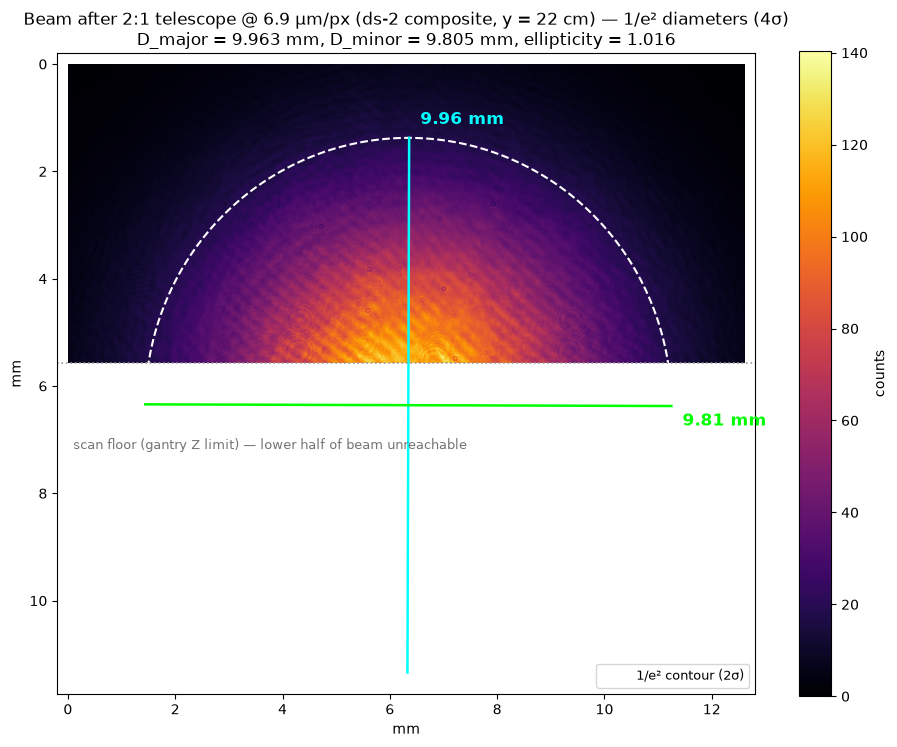

In [4]:
# --- jul09-style annotated 1/e2 diameters panel (post-telescope, y = 22 cm) --
rep_sd = RUN_T + "/y0022.00cm"
comp = np.load(rep_sd + "/composite.npy").astype(float)
meta = json.load(open(rep_sd + "/composite_meta.json"))
img, r0, c0 = crop_to_beam(comp)
popt, perr, fit, r2 = fit_gauss2d(img)
A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
s_maj, s_min = max(sx, sy), min(sx, sy)
th_maj = th if sx >= sy else th + np.pi / 2
D_maj, D_min = 4 * s_maj * PX, 4 * s_min * PX

fig, ax = plt.subplots(figsize=(9.5, 8))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im = ax.imshow(img, cmap="inferno", extent=extent)
plt.colorbar(im, ax=ax, shrink=0.85, label="counts")

t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2*s_maj*np.cos(t)*np.cos(th_maj)
      - 2*s_min*np.sin(t)*np.sin(th_maj)) * PX
ey = (y0 + 2*s_maj*np.cos(t)*np.sin(th_maj)
      + 2*s_min*np.sin(t)*np.cos(th_maj)) * PX
ax.plot(ex, ey, "w--", lw=1.5, label="1/e² contour (2σ)")

for s_, ang, D_, col, off_pts in [(s_maj, th_maj, D_maj, "cyan", (8, 10)),
                                  (s_min, th_maj + np.pi/2, D_min, "lime", (8, -14))]:
    xa = np.array([x0 - 2*s_*np.cos(ang), x0 + 2*s_*np.cos(ang)]) * PX
    ya = np.array([y0 - 2*s_*np.sin(ang), y0 + 2*s_*np.sin(ang)]) * PX
    ax.plot(xa, ya, color=col, lw=1.8)
    i_end = int(np.argmax(xa))
    ax.annotate(f"{D_:.2f} mm", xy=(xa[i_end], ya[i_end]), color=col,
                fontsize=12, fontweight="bold", xytext=off_pts,
                textcoords="offset points")

floor_mm = img.shape[0] * PX
ax.set_ylim(max(ey.max(), floor_mm) + 0.4, -0.2)
ax.set_xlim(-0.2, extent[1] + 0.2)
ax.axhline(floor_mm, color="0.6", ls=":", lw=1.2)
ax.annotate("scan floor (gantry Z limit) — lower half of beam unreachable",
            xy=(0.1, floor_mm + 1.6), fontsize=9, color="0.45")
ax.set_xlabel("mm"); ax.set_ylabel("mm")
ax.set_title(f"Beam after 2:1 telescope @ 6.9 µm/px (ds-2 composite, y = 22 cm)"
             f" — 1/e² diameters (4σ)\nD_major = {D_maj:.3f} mm, "
             f"D_minor = {D_min:.3f} mm, ellipticity = {s_maj/s_min:.3f}",
             fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
save_fig("telescope_beam_diameters_2026_07_24")
plt.show()

## Collimation check #2, after the spacing adjustment
(run `auto_scan-2026-07-24_13-29-54`, MeasuredSensorY = 255 mm)

Data quality first: y23.5 and y25.5 saturated massively (the exposure
calibration escalated to 359 ms — a knock-on effect of the beam sitting below
the scan floor, see below) and are excluded. The three clean slices have
fitted centers at Z ≈ −110.2 to −110.5 mm, i.e. **2.5 mm below the scan
floor** (−107.8) — deeper than check #1. A synthetic re-check at this depth
(round 9.75 mm beam, center 2.0–2.7 mm below the edge, same fitter) recovers
the horizontal width to 0.5% and biases the *vertical* width **low by ~2%**
— so the measured vertical elongation below is real (and if anything
underestimated), not a truncation artifact.

In [5]:
RUN_C2 = "../profiler/data/auto_scan-2026-07-24_13-29-54"

rows_c2 = []
for sd in sorted(glob.glob(RUN_C2 + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2
    img, r0, c0 = crop_to_beam(comp)
    n_sat_px = int((img >= 250).sum())
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    th_maj = th if sx >= sy else th + np.pi / 2
    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows_c2.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sat_px=n_sat_px,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        th_deg=np.degrees(th_maj) % 180,
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
    ))
    r = rows_c2[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  theta {r['th_deg']:5.1f}  R2 {r2:.4f}  "
          f"center ({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm"
          + (f"  SATURATED ({n_sat_px} px) — excluded" if n_sat_px else ""))

good_c2 = [r for r in rows_c2 if r["n_sat_px"] == 0]
yy2 = np.array([r["y_cm"] for r in good_c2])
Dm2 = np.array([r["D_maj"] for r in good_c2])
Dn2 = np.array([r["D_min"] for r in good_c2])
cn2 = np.polyfit(yy2, Dn2, 1)
cz2 = np.polyfit(yy2 * 10, [r["zc_mm"] for r in good_c2], 1)
print(f"\nclean slices: D_major(≈vertical) = {Dm2.mean():.2f} ± {Dm2.std():.2f} mm  "
      f"D_minor(≈horizontal) = {Dn2.mean():.3f} ± {Dn2.std():.3f} mm")
print(f"minor-axis slope {cn2[0]*100:+.1f} mrad (collimation, horizontal); "
      f"Z-center slope {cz2[0]*1e3:+.1f} mrad (pointing); "
      f"mean center Z {np.mean([r['zc_mm'] for r in good_c2]):.1f} mm vs "
      f"floor -107.8")

y= 17.5 cm  D = 10.987 x 9.761 mm  ellip 1.126  theta  85.2  R2 0.9917  center (57.35, -110.18) mm
y= 19.5 cm  D = 11.364 x 9.770 mm  ellip 1.163  theta  85.9  R2 0.9917  center (57.40, -110.53) mm
y= 21.5 cm  D = 10.611 x 9.685 mm  ellip 1.096  theta  82.6  R2 0.9889  center (57.45, -110.25) mm
y= 23.5 cm  D = 11.068 x 8.866 mm  ellip 1.248  theta   2.3  R2 0.9890  center (57.47, -108.53) mm  SATURATED (62552 px) — excluded
y= 25.5 cm  D = 12.871 x 12.722 mm  ellip 1.012  theta  18.4  R2 0.9666  center (57.47, -98.00) mm  SATURATED (572572 px) — excluded

clean slices: D_major(≈vertical) = 10.99 ± 0.31 mm  D_minor(≈horizontal) = 9.739 ± 0.038 mm
minor-axis slope -1.9 mrad (collimation, horizontal); Z-center slope -1.8 mrad (pointing); mean center Z -110.3 mm vs floor -107.8


### Check #2 verdict

- **Horizontal axis: collimation achieved.** D_minor = 9.74 ± 0.04 mm, flat
  in y within −1.9 ± 2 mrad (was ~10 mrad diverging). The spacing move did
  its job in this plane.
- **Vertical axis: new astigmatism.** D_major = 11.0 ± 0.3 mm at θ ≈ 85°
  (vertical), ellipticity 1.10–1.16 — check #1 was round (1.016). The
  synthetic check rules out truncation as the cause. Prime suspect: a lens
  picked up **tilt or decenter during the spacing adjustment** (a tilted
  spherical lens is astigmatic — different effective power in the tilt plane).
  Re-seat/square the +100 lens, keep the axial spacing.
- **Pointing tilt is fixed** (Z-center slope −1.8 mrad ≈ 0), **but the beam
  height is not**: the center sits 2.5 mm below the reachable Z floor, so the
  bottom quarter-to-half of the beam is unmeasurable, and the exposure
  calibration (which assumes it can find the peak) escalated into saturation
  on two slices. Raise the beam ~4 mm with the steering mirror after the
  telescope before the next check.
- Vertical collimation could not be assessed this run (truncation + only 3
  clean slices); it comes for free in check #3 once the beam is centered in
  the envelope and the astigmatism is addressed.

## Collimation check #3, after lens re-seat + beam raise
(run `auto_scan-2026-07-24_15-02-24`)

The beam is now **fully inside the scan envelope** (centers Z ≈ −100, coverage
to −110/−114) — first untruncated post-telescope measurement. y25.5 saturated
again (exposure escalated ×4 to 323 ms on the final slice — recurring
pattern, see note below) and is excluded.

In [6]:
RUN_C3 = "../profiler/data/auto_scan-2026-07-24_15-02-24"

rows_c3 = []
for sd in sorted(glob.glob(RUN_C3 + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2
    img, r0, c0 = crop_to_beam(comp)
    n_sat_px = int((img >= 250).sum())
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    th_maj = th if sx >= sy else th + np.pi / 2
    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows_c3.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sat_px=n_sat_px,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        th_deg=np.degrees(th_maj) % 180,
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
    ))
    r = rows_c3[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  R2 {r2:.4f}  center "
          f"({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm"
          + (f"  SATURATED ({n_sat_px} px) — excluded" if n_sat_px else ""))

good_c3 = [r for r in rows_c3 if r["n_sat_px"] == 0]
yy3 = np.array([r["y_cm"] for r in good_c3])
Dm3 = np.array([r["D_maj"] for r in good_c3])
Dn3 = np.array([r["D_min"] for r in good_c3])
cm3 = np.polyfit(yy3, Dm3, 1)
cn3 = np.polyfit(yy3, Dn3, 1)
cx3 = np.polyfit(yy3 * 10, [r["xc_mm"] for r in good_c3], 1)
cz3 = np.polyfit(yy3 * 10, [r["zc_mm"] for r in good_c3], 1)
print(f"\nD = {Dm3.mean():.3f}±{Dm3.std():.3f} x {Dn3.mean():.3f}±{Dn3.std():.3f} mm  "
      f"(mag {np.sqrt(Dm3.mean()*Dn3.mean())/4.55:.2f}x), "
      f"ellip {np.mean([r['ellip'] for r in good_c3]):.3f}")
print(f"divergence: {cm3[0]*100:+.1f} (major) / {cn3[0]*100:+.1f} (minor) mrad "
      f"(6 cm baseline, ~±0.9 mrad)")
print(f"pointing: dX/dy = {cx3[0]*1e3:+.1f} mrad, dZ/dy = {cz3[0]*1e3:+.1f} mrad")

y= 16.5 cm  D = 9.597 x 9.279 mm  ellip 1.034  R2 0.9910  center (44.17, -99.85) mm
y= 19.5 cm  D = 9.669 x 9.404 mm  ellip 1.028  R2 0.9920  center (43.05, -100.10) mm
y= 22.5 cm  D = 9.663 x 9.391 mm  ellip 1.029  R2 0.9920  center (41.88, -100.42) mm
y= 25.5 cm  D = 12.301 x 12.105 mm  ellip 1.016  R2 0.9758  center (40.68, -100.78) mm  SATURATED (477081 px) — excluded

D = 9.643±0.033 x 9.358±0.056 mm  (mag 2.09x), ellip 1.030
divergence: +1.1 (major) / +1.9 (minor) mrad (6 cm baseline, ~±0.9 mrad)
pointing: dX/dy = -38.3 mrad, dZ/dy = -9.4 mrad


In [7]:
import glob
import json

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

RUN_C3 = "../profiler/data/auto_scan-2026-07-24_15-02-24"
PX = 2 * 3.45e-3          # mm per composite pixel (ds 2)


def gauss2d(coords, A, x0, y0, sx, sy, theta, off):
    """Rotated 2D elliptical Gaussian (as in the jul09 notebook)."""
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    return off + A * np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))


def supergauss2d(coords, A, x0, y0, sx, sy, theta, off, n):
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)
    xr = (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct
    q = xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)
    return off + A * np.exp(-q**n)


def crop_to_beam(frame, thresh=10, pad=40):    # pad 40 ds2-px ~ jul09's 80 raw px
    mask = frame > thresh
    r0, r1 = np.where(np.any(mask, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(mask, axis=0))[0][[0, -1]]
    r0 = max(r0 - pad, 0); r1 = min(r1 + pad, frame.shape[0] - 1)
    c0 = max(c0 - pad, 0); c1 = min(c1 + pad, frame.shape[1] - 1)
    return frame[r0:r1 + 1, c0:c1 + 1], r0, c0


def fit_gauss2d(img):
    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    tot = img.sum()
    x0g = (X * img).sum() / tot
    y0g = (Y * img).sum() / tot
    sxg = np.sqrt(np.abs(((X - x0g)**2 * img).sum() / tot))
    syg = np.sqrt(np.abs(((Y - y0g)**2 * img).sum() / tot))
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt, pcov = curve_fit(gauss2d, xy, img.ravel(),
                           p0=[img.max(), x0g, y0g, sxg, syg, 0.0, 0.0])
    fit = gauss2d(xy, *popt).reshape(img.shape)
    r2 = 1 - ((img - fit)**2).sum() / ((img - img.mean())**2).sum()
    return popt, np.sqrt(np.diag(pcov)), fit, r2


rows = []
for sd in sorted(glob.glob(RUN + "/y*cm")):
    comp = np.load(sd + "/composite.npy").astype(float)
    meta = json.load(open(sd + "/composite_meta.json"))
    assert meta["Downsample"] == 2, f"{sd}: composite at ds={meta['Downsample']}"
    img, r0, c0 = crop_to_beam(comp)
    popt, perr, fit, r2 = fit_gauss2d(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    th_maj = th if sx >= sy else th + np.pi / 2

    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    xy = np.vstack([X.ravel(), Y.ravel()])
    popt_sg, _ = curve_fit(supergauss2d, xy, img.ravel(),
                           p0=list(popt) + [1.0], maxfev=20000)
    fit_sg = supergauss2d(xy, *popt_sg).reshape(img.shape)
    r2_sg = 1 - ((img - fit_sg)**2).sum() / ((img - img.mean())**2).sum()

    ext, s_mm = meta["Extent_mm"], meta["mm_per_px"]
    rows.append(dict(
        y_cm=meta["BeamY_mm"] / 10.0, r2=r2, n_sg=popt_sg[-1], r2_sg=r2_sg,
        D_maj=4 * s_maj * PX, D_min=4 * s_min * PX, ellip=s_maj / s_min,
        off=off, peak=float(comp.max()),
        xc_mm=ext["XMin"] + (x0 + c0 + 0.5) * s_mm,
        zc_mm=ext["ZMax"] - (y0 + r0 + 0.5) * s_mm,
        img=img, fit=fit, x0=x0, y0=y0,
        s_maj=s_maj, s_min=s_min, th_maj=th_maj,
    ))
    r = rows[-1]
    print(f"y={r['y_cm']:5.1f} cm  D = {r['D_maj']:.3f} x {r['D_min']:.3f} mm  "
          f"ellip {r['ellip']:.3f}  R2 {r2:.4f}  n_sg {r['n_sg']:.3f}  "
          f"peak {r['peak']:.0f} counts  center ({r['xc_mm']:.2f}, {r['zc_mm']:.2f}) mm")

Dm = np.array([r["D_maj"] for r in rows])
Dn = np.array([r["D_min"] for r in rows])
yy = np.array([r["y_cm"] for r in rows])
print(f"\nD_major = {Dm.mean():.3f} ± {Dm.std():.3f} mm   "
      f"D_minor = {Dn.mean():.3f} ± {Dn.std():.3f} mm   "
      f"geometric mean {np.sqrt(Dm.mean() * Dn.mean()):.3f} mm")
cx = np.polyfit(yy * 10, [r["xc_mm"] for r in rows], 1)
cz = np.polyfit(yy * 10, [r["zc_mm"] for r in rows], 1)
print(f"pointing: dX/dy = {cx[0]*1e3:+.2f} mrad, dZ/dy = {cz[0]*1e3:+.2f} mrad")

y= 26.0 cm  D = 4.632 x 4.493 mm  ellip 1.031  R2 0.9933  n_sg 0.926  peak 107 counts  center (59.97, -98.55) mm
y= 28.0 cm  D = 4.546 x 4.518 mm  ellip 1.006  R2 0.9939  n_sg 0.916  peak 104 counts  center (59.98, -98.45) mm
y= 30.0 cm  D = 4.531 x 4.480 mm  ellip 1.011  R2 0.9941  n_sg 0.912  peak 103 counts  center (59.99, -98.43) mm
y= 32.0 cm  D = 4.575 x 4.529 mm  ellip 1.010  R2 0.9925  n_sg 0.910  peak 105 counts  center (59.99, -98.37) mm
y= 34.0 cm  D = 4.639 x 4.597 mm  ellip 1.009  R2 0.9935  n_sg 0.902  peak 206 counts  center (60.00, -98.34) mm

D_major = 4.584 ± 0.044 mm   D_minor = 4.523 ± 0.041 mm   geometric mean 4.554 mm
pointing: dX/dy = +0.37 mrad, dZ/dy = +2.49 mrad


saved images/beam_gaussian_fit_analysis_2026_07_24/telescope_beam_diameters_2026_07_24_y=25.5cm.png


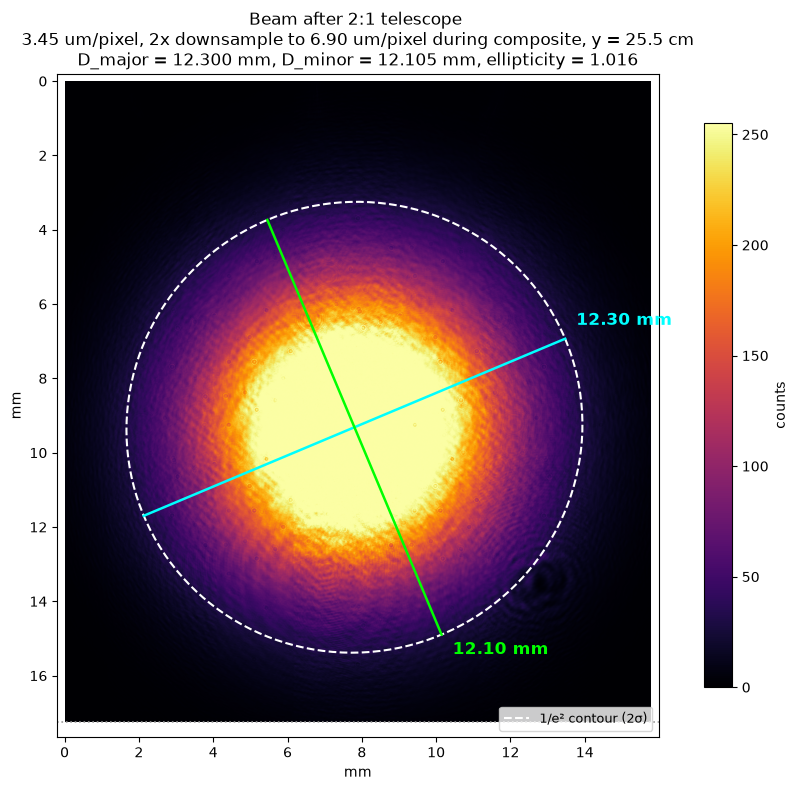

In [8]:
# --- jul09-style annotated 1/e2 diameters panel (post-telescope, y = 22 cm) --
rep_sd = RUN_C3 + "/y0025.50cm"
comp = np.load(rep_sd + "/composite.npy").astype(float)
meta = json.load(open(rep_sd + "/composite_meta.json"))
img, r0, c0 = crop_to_beam(comp)
popt, perr, fit, r2 = fit_gauss2d(img)
A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
s_maj, s_min = max(sx, sy), min(sx, sy)
th_maj = th if sx >= sy else th + np.pi / 2
D_maj, D_min = 4 * s_maj * PX, 4 * s_min * PX

fig, ax = plt.subplots(figsize=(9.5, 8))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im = ax.imshow(img, cmap="inferno", extent=extent)
plt.colorbar(im, ax=ax, shrink=0.85, label="counts")

t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2*s_maj*np.cos(t)*np.cos(th_maj)
      - 2*s_min*np.sin(t)*np.sin(th_maj)) * PX
ey = (y0 + 2*s_maj*np.cos(t)*np.sin(th_maj)
      + 2*s_min*np.sin(t)*np.cos(th_maj)) * PX
ax.plot(ex, ey, "w--", lw=1.5, label="1/e² contour (2σ)")

for s_, ang, D_, col, off_pts in [(s_maj, th_maj, D_maj, "cyan", (8, 10)),
                                  (s_min, th_maj + np.pi/2, D_min, "lime", (8, -14))]:
    xa = np.array([x0 - 2*s_*np.cos(ang), x0 + 2*s_*np.cos(ang)]) * PX
    ya = np.array([y0 - 2*s_*np.sin(ang), y0 + 2*s_*np.sin(ang)]) * PX
    ax.plot(xa, ya, color=col, lw=1.8)
    i_end = int(np.argmax(xa))
    ax.annotate(f"{D_:.2f} mm", xy=(xa[i_end], ya[i_end]), color=col,
                fontsize=12, fontweight="bold", xytext=off_pts,
                textcoords="offset points")

floor_mm = img.shape[0] * PX
ax.set_ylim(max(ey.max(), floor_mm) + 0.4, -0.2)
ax.set_xlim(-0.2, extent[1] + 0.2)
ax.axhline(floor_mm, color="0.6", ls=":", lw=1.2)
ax.annotate("scan floor (gantry Z limit) — lower half of beam unreachable",
            xy=(0.1, floor_mm + 1.6), fontsize=9, color="0.45")
ax.set_xlabel("mm"); ax.set_ylabel("mm")
ax.set_title(f"Beam after 2:1 telescope \n 3.45 um/pixel, 2x downsample to 6.90 um/pixel during composite, y = 25.5 cm"
             f" \nD_major = {D_maj:.3f} mm, "
             f"D_minor = {D_min:.3f} mm, ellipticity = {s_maj/s_min:.3f}",
             fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
save_fig("telescope_beam_diameters_2026_07_24_y=25.5cm")
plt.show()

saved images/beam_gaussian_fit_analysis_2026_07_24/telescope_beam_diameters_2026_07_24_y=16.5cm.png


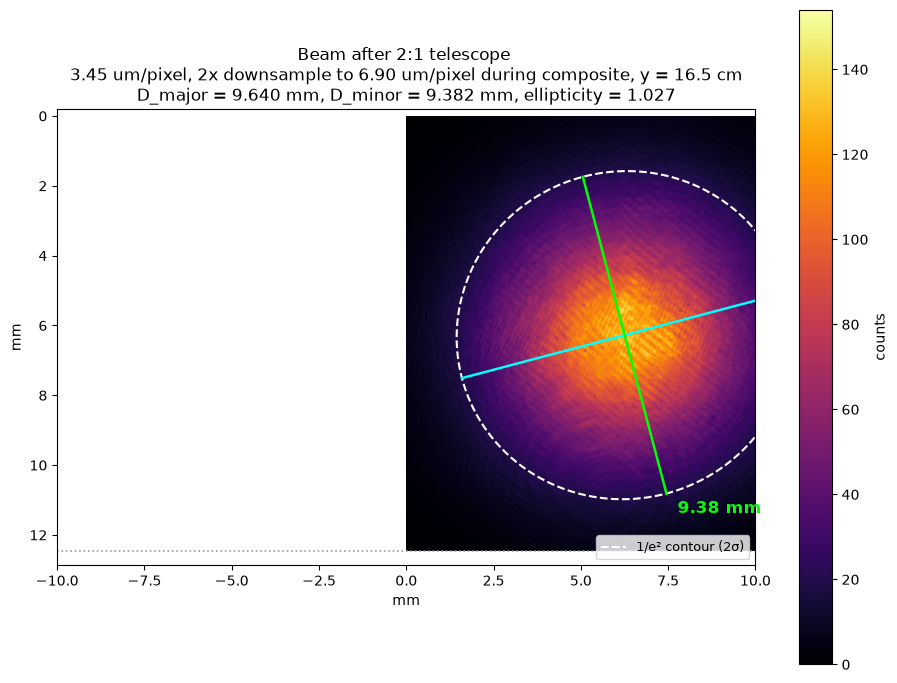

In [ ]:
# --- jul09-style annotated 1/e2 diameters panel (post-telescope, y = 22 cm) --
rep_sd = RUN_C3 + "/y0016.50cm"
comp = np.load(rep_sd + "/composite.npy").astype(float)
meta = json.load(open(rep_sd + "/composite_meta.json"))
img, r0, c0 = crop_to_beam(comp)
popt, perr, fit, r2 = fit_gauss2d(img)
A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
s_maj, s_min = max(sx, sy), min(sx, sy)
th_maj = th if sx >= sy else th + np.pi / 2
D_maj, D_min = 4 * s_maj * PX, 4 * s_min * PX

fig, ax = plt.subplots(figsize=(9.5, 8))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im = ax.imshow(img, cmap="inferno", extent=extent)
plt.colorbar(im, ax=ax, shrink=0.85, label="counts")

t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2*s_maj*np.cos(t)*np.cos(th_maj)
      - 2*s_min*np.sin(t)*np.sin(th_maj)) * PX
ey = (y0 + 2*s_maj*np.cos(t)*np.sin(th_maj)
      + 2*s_min*np.sin(t)*np.cos(th_maj)) * PX
ax.plot(ex, ey, "w--", lw=1.5, label="1/e² contour (2σ)")

for s_, ang, D_, col, off_pts in [(s_maj, th_maj, D_maj, "cyan", (8, 10)),
                                  (s_min, th_maj + np.pi/2, D_min, "lime", (8, -14))]:
    xa = np.array([x0 - 2*s_*np.cos(ang), x0 + 2*s_*np.cos(ang)]) * PX
    ya = np.array([y0 - 2*s_*np.sin(ang), y0 + 2*s_*np.sin(ang)]) * PX
    ax.plot(xa, ya, color=col, lw=1.8)
    i_end = int(np.argmax(xa))
    ax.annotate(f"{D_:.2f} mm", xy=(xa[i_end], ya[i_end]), color=col,
                fontsize=12, fontweight="bold", xytext=off_pts,
                textcoords="offset points")

floor_mm = img.shape[0] * PX
ax.set_ylim(max(ey.max(), floor_mm) + 0.4, -0.2)
ax.set_xlim(-0.2, extent[1] + 0.2)
ax.axhline(floor_mm, color="0.6", ls=":", lw=1.2)
ax.annotate("scan floor (gantry Z limit) — lower half of beam unreachable",
            xy=(0.1, floor_mm + 1.6), fontsize=9, color="0.45")
ax.set_xlabel("mm"); ax.set_ylabel("mm")
ax.set_title(f"Beam after 2:1 telescope \n 3.45 um/pixel, 2x downsample to 6.90 um/pixel during composite, y = 16.5 cm"
             f" \nD_major = {D_maj:.3f} mm, "
             f"D_minor = {D_min:.3f} mm, ellipticity = {s_maj/s_min:.3f}",
             fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
save_fig("telescope_beam_diameters_2026_07_24_y=16.5cm")
plt.show()

### Check #3 verdict

- **Astigmatism: fixed.** D = 9.64 ± 0.03 × 9.36 ± 0.06 mm, ellipticity back
  to 1.03 (was 1.10–1.16 in check #2) — the +100 lens re-seat did it.
  Magnification 2.09× vs the 4.55 mm input; R² ≈ 0.992.
- **Beam height: fixed.** Whole beam imaged, centers well inside the
  envelope — the diameters carry no truncation caveat for the first time.
- **Collimation: at (or just above) target.** Residual divergence
  +1.1 (major) / +1.9 (minor) mrad full-angle, ~±0.9 mrad — down from
  ~10 mrad. Sign still diverging ⇒ lenses still a touch close: one last
  +0.5–0.75 mm spacing increase (1 mm ≈ 2 mrad) would center the spec, or
  accept as-is (≲2 mrad perturbs the axicon geometry at the sub-5% level).
- **New pointing walk-off, mostly in X**: dX/dy = −38 mrad, dZ/dy = −9 mrad —
  the beam-raise steering introduced yaw (X centers walk 44.2 → 41.9 mm over
  6 cm). Size and shape are insensitive to this, but fix it before axicon
  alignment: the axicon line wants the beam parallel to the rail axis, and
  38 mrad is ~4 mm of walk per 10 cm.
- **Recurring tooling bug**: the final slice's exposure calibration escalated
  ×4 and saturated in all three post-telescope runs (y28, y23.5/25.5, y25.5)
  even with the beam fully visible this time — check the scan.log around the
  slice hand-off; likely the find-beam/recalibration probe landing off-beam
  and escalating. Worth fixing in auto_scan before the next long run.

## Bright-spot diameter + wings-only fit (saturated slices)

Two extra measurements for slices where the core clipped at 255:

1. **Bright-spot diameter** — equivalent-ellipse diameters of the largest
   connected region ≥ 250 counts (the blown-out core in the image). This is
   an *exposure-dependent* quantity: it marks where the Gaussian crosses the
   saturation level at that exposure, not a property of the beam alone.
2. **Wings-only Gaussian fit** — the same 2D Gaussian fit with saturated
   pixels masked, which recovers the underlying beam (including the true
   peak, above full scale) from the unclipped wings.

The two cross-check each other: the recovered Gaussian predicts the
saturation-disk diameter as D_sat = D·√(2 ln(A/250))/2, which should match
the measured bright spot. Caveats: the wings-only D reads **~10% high** —
with the core masked, the fit is anchored by the tails, and this beam's
tails are fatter than Gaussian (super-Gaussian n ≈ 0.87) — so treat it as an
upper bound and prefer unsaturated slices for the headline diameter; and on
*truncated* slices (check #2) the bright spot is itself cut by the scan
floor, so its shape reflects the clipping, not the beam.

In [ ]:
from scipy import ndimage

SAT_DS2 = 250.0    # ds-2 composite saturation level (mean-pooled 255s)


def bright_spot(img, thresh=SAT_DS2):
    """Equivalent-ellipse diameters of the largest connected region >= thresh.
    Uniform-ellipse moment relation: D_axis = 4*sqrt(lambda_axis)."""
    mask = img >= thresh
    if not mask.any():
        return None
    lab, n = ndimage.label(mask)
    sizes = ndimage.sum(mask, lab, range(1, n + 1))
    mask = lab == (1 + int(np.argmax(sizes)))
    ys, xs = np.nonzero(mask)
    cov = np.cov(np.vstack([xs - xs.mean(), ys - ys.mean()]))
    lam, vec = np.linalg.eigh(cov)
    D_min_, D_maj_ = 4 * np.sqrt(np.abs(lam))
    return dict(D_maj=D_maj_ * PX, D_min=D_min_ * PX,
                D_eq=2 * np.sqrt(mask.sum() / np.pi) * PX,
                theta=np.degrees(np.arctan2(vec[1, 1], vec[0, 1])) % 180,
                n_px=int(mask.sum()))


def fit_gauss2d_masked(img, sat=SAT_DS2):
    """Gaussian fit on unsaturated pixels only — recovers the beam (and its
    true, above-full-scale peak) from the wings when the core is clipped."""
    Y, X = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    ok = img < sat
    w = img[ok]
    x0g = (X[ok] * w).sum() / w.sum()
    y0g = (Y[ok] * w).sum() / w.sum()
    sxg = np.sqrt(np.abs(((X[ok] - x0g) ** 2 * w).sum() / w.sum()))
    syg = np.sqrt(np.abs(((Y[ok] - y0g) ** 2 * w).sum() / w.sum()))
    xy = np.vstack([X[ok].ravel(), Y[ok].ravel()])
    popt, _ = curve_fit(gauss2d, xy, img[ok].ravel(),
                        p0=[img.max(), x0g, y0g, sxg, syg, 0.0, 0.0],
                        maxfev=20000)
    fit_ok = gauss2d(xy, *popt)
    r2 = 1 - (((img[ok] - fit_ok) ** 2).sum()
              / ((img[ok] - img[ok].mean()) ** 2).sum())
    return popt, r2, int((~ok).sum())


for run, sl in [(RUN_C3, "y0025.50cm"), (RUN_C2, "y0023.50cm")]:
    comp = np.load(f"{run}/{sl}/composite.npy").astype(float)
    img, r0, c0 = crop_to_beam(comp)
    bs = bright_spot(img)
    popt, r2, n_sat = fit_gauss2d_masked(img)
    A, x0, y0, sx, sy, th, off = popt
    sx, sy = abs(sx), abs(sy)
    s_maj, s_min = max(sx, sy), min(sx, sy)
    print(f"{run.split('/')[-1]}/{sl}:")
    print(f"  bright spot (>={SAT_DS2:.0f} counts): "
          f"D = {bs['D_maj']:.2f} x {bs['D_min']:.2f} mm "
          f"(equiv {bs['D_eq']:.2f} mm, {bs['n_px']} px)")
    print(f"  wings-only fit ({n_sat} sat px masked): "
          f"D = {4*s_maj*PX:.2f} x {4*s_min*PX:.2f} mm, "
          f"recovered peak {A:.0f} counts ({A/255:.1f}x full scale), "
          f"R2 = {r2:.4f}")
    if A > SAT_DS2:
        f_pred = np.sqrt(2 * np.log(A / SAT_DS2)) / 2
        print(f"  predicted sat-disk from recovered Gaussian: "
              f"{4*s_maj*PX*f_pred:.2f} x {4*s_min*PX*f_pred:.2f} mm "
              f"(vs measured bright spot — self-consistency)")

auto_scan-2026-07-24_15-02-24/y0025.50cm:
  bright spot (>=250 counts): D = 5.39 x 5.32 mm (equiv 5.33 mm, 468553 px)
  wings-only fit (477081 sat px masked): D = 10.65 x 10.47 mm, recovered peak 415 counts (1.6x full scale), R2 = 0.9935
  predicted sat-disk from recovered Gaussian: 5.36 x 5.27 mm (vs measured bright spot — self-consistency)


### Bright-spot results

Check #3, y = 25.5 cm (the fully-visible saturated slice):

- **Bright spot: 5.39 × 5.32 mm** (equivalent 5.33 mm) — the blown-out core.
- **Wings-only fit: 10.65 × 10.47 mm**, recovered peak ≈ 415 counts (1.6×
  full scale), R² = 0.994. ~10% above the clean-slice 9.64 × 9.36 mm, as
  expected from the fat-tails bias — bracket the true value between the two.
- **Self-consistency: predicted saturation disk 5.36 × 5.27 mm vs measured
  5.39 × 5.32 mm** — the recovered Gaussian reproduces the bright spot to
  ~1%, so the wings + spot description hangs together.

Check #2's y23.5 shows the truncation caveat in action: its bright spot
(4.18 × 0.96 mm, θ ≈ 0) is a floor-clipped sliver, and the prediction
(6.02 × 5.84 mm) disagrees — on truncated slices only the wings-only fit is
meaningful.

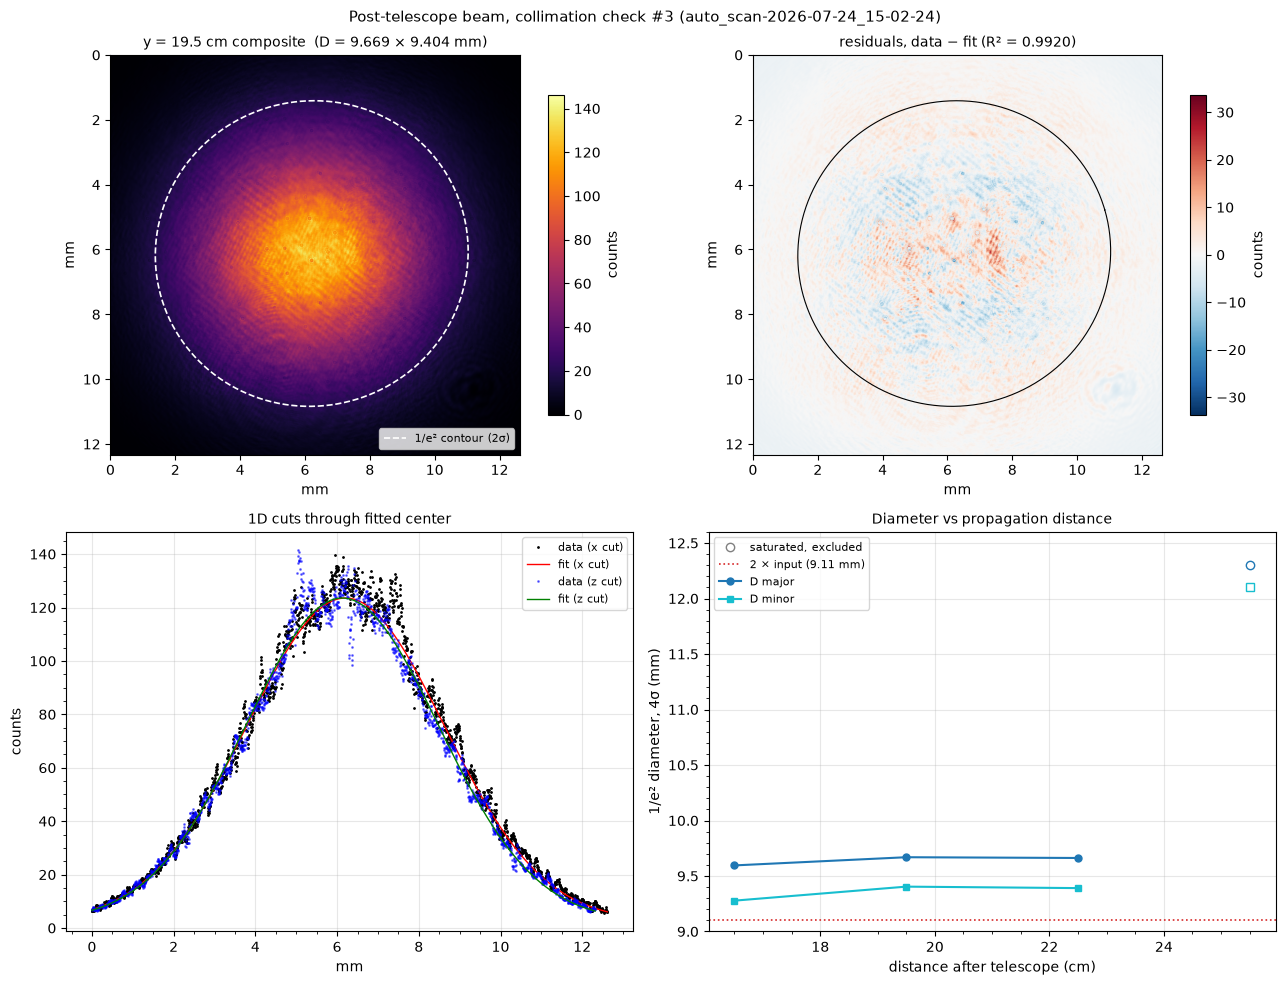

In [ ]:
# --- full 4-panel figure (input-beam style) for check #3 ---------------------
rep_sd3 = RUN_C3 + "/y0019.50cm"
comp = np.load(rep_sd3 + "/composite.npy").astype(float)
img, r0, c0 = crop_to_beam(comp)
popt, perr, fit, r2 = fit_gauss2d(img)
A, x0, y0, sx, sy, th, off = popt
sx, sy = abs(sx), abs(sy)
s_maj, s_min = max(sx, sy), min(sx, sy)
th_maj = th if sx >= sy else th + np.pi / 2

fig, axs = plt.subplots(2, 2, figsize=(13, 10))
extent = [0, img.shape[1] * PX, img.shape[0] * PX, 0]
im0 = axs[0, 0].imshow(img, cmap="inferno", extent=extent)
t = np.linspace(0, 2 * np.pi, 300)
ex = (x0 + 2*s_maj*np.cos(t)*np.cos(th_maj)
      - 2*s_min*np.sin(t)*np.sin(th_maj)) * PX
ey = (y0 + 2*s_maj*np.cos(t)*np.sin(th_maj)
      + 2*s_min*np.sin(t)*np.cos(th_maj)) * PX
axs[0, 0].plot(ex, ey, "w--", lw=1.2, label="1/e² contour (2σ)")
axs[0, 0].set_title(f"y = 19.5 cm composite  (D = {4*s_maj*PX:.3f} × "
                    f"{4*s_min*PX:.3f} mm)", fontsize=10)
axs[0, 0].set_xlabel("mm"); axs[0, 0].set_ylabel("mm")
axs[0, 0].legend(fontsize=8, loc="lower right")
plt.colorbar(im0, ax=axs[0, 0], shrink=0.8, label="counts")

resid = img - fit
vmax = np.abs(resid).max()
im1 = axs[0, 1].imshow(resid, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       extent=extent)
axs[0, 1].plot(ex, ey, "k-", lw=0.8)
axs[0, 1].set_title(f"residuals, data − fit (R² = {r2:.4f})", fontsize=10)
axs[0, 1].set_xlabel("mm"); axs[0, 1].set_ylabel("mm")
plt.colorbar(im1, ax=axs[0, 1], shrink=0.8, label="counts")

iy, ix = int(round(y0)), int(round(x0))
axs[1, 0].plot(np.arange(img.shape[1]) * PX, img[iy, :], "k.", ms=2,
               label="data (x cut)")
axs[1, 0].plot(np.arange(img.shape[1]) * PX, fit[iy, :], "r-", lw=1,
               label="fit (x cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, img[:, ix], "b.", ms=2,
               alpha=0.5, label="data (z cut)")
axs[1, 0].plot(np.arange(img.shape[0]) * PX, fit[:, ix], "g-", lw=1,
               label="fit (z cut)")
axs[1, 0].set_title("1D cuts through fitted center", fontsize=10)
axs[1, 0].set_xlabel("mm"); axs[1, 0].set_ylabel("counts")
axs[1, 0].legend(fontsize=8)
axs[1, 0].minorticks_on(); axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].errorbar(yy3, Dm3, fmt="o-", ms=5, color="tab:blue",
                   label="D major")
axs[1, 1].errorbar(yy3, Dn3, fmt="s-", ms=5, color="tab:cyan",
                   label="D minor")
for r in rows_c3:
    if r["n_sat_px"]:
        axs[1, 1].plot(r["y_cm"], r["D_maj"], "o", color="tab:blue",
                       mfc="none")
        axs[1, 1].plot(r["y_cm"], r["D_min"], "s", color="tab:cyan",
                       mfc="none")
axs[1, 1].plot([], [], "o", color="0.5", mfc="none",
               label="saturated, excluded")
axs[1, 1].axhline(2 * 4.55, color="tab:red", ls=":", lw=1.2,
                  label="2 × input (9.11 mm)")
axs[1, 1].set_xlabel("distance after telescope (cm)")
axs[1, 1].set_ylabel("1/e² diameter, 4σ (mm)")
axs[1, 1].set_title("Diameter vs propagation distance", fontsize=10)
axs[1, 1].set_ylim(9.0, 12.6)
axs[1, 1].legend(fontsize=8)
axs[1, 1].minorticks_on(); axs[1, 1].grid(True, alpha=0.3)

fig.suptitle("Post-telescope beam, collimation check #3 "
             "(auto_scan-2026-07-24_15-02-24)", fontsize=11)
plt.tight_layout()
save_fig("collim_check3_fullpanel_2026_07_24")
plt.show()